In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson, lognorm

In [3]:
df = pd.read_excel("D:/New Resumes/Latest/Projects/Reinsurance Risk Modelling/Data/EM_DAT.xlsx")

print(df.head())

          DisNo.  Year Historic Classification Key Disaster Group  \
0  2000-0020-IND  2000       No    nat-met-ext-col        Natural   
1  2000-0306-IND  2000       No    nat-bio-epi-vir        Natural   
2  2000-0308-IND  2000       No    nat-bio-epi-bac        Natural   
3  2000-0332-IND  2000       No    nat-hyd-flo-fla        Natural   
4  2000-0358-IND  2000       No    nat-hyd-mmw-lan        Natural   

  Disaster Subgroup        Disaster Type   Disaster Subtype External IDs  \
0    Meteorological  Extreme temperature          Cold wave          NaN   
1        Biological             Epidemic      Viral disease          NaN   
2        Biological             Epidemic  Bacterial disease          NaN   
3      Hydrological                Flood        Flash flood          NaN   
4      Hydrological  Mass movement (wet)    Landslide (wet)          NaN   

  Event Name  ... Reconstruction Costs, Adjusted ('000 US$)  \
0        NaN  ...                                       NaN   
1 

In [4]:
df = df.rename(columns={
    'Disaster Type': 'disaster_type',
    'Country': 'country',
    'Year': 'year',
    "Total Damage ('000 US$)": 'damage'
})

# Filter India + Flood & Storm
df = df[
    (df['country'] == 'India') &
    (df['disaster_type'].isin(['Flood', 'Storm'])) &
    (df['damage'].notna())
]

# Convert to USD
df['damage_usd'] = df['damage'] * 1000

print("Filtered rows:", len(df))

Filtered rows: 103


In [5]:
portfolio = pd.read_excel("D:/New Resumes/Latest/Projects/Reinsurance Risk Modelling/Data/insurance_portfolio.xlsx")  # your file

print(portfolio.head())

   asset_id    location  latitude  longitude  insured_value_usd   asset_type  \
0      1001       Surat   21.0755    72.8436            1619000   Commercial   
1      1002  Chandigarh   30.8449    76.8487             880000   Commercial   
2      1003      Jaipur   27.0040    75.8346             192000  Residential   
3      1004       Delhi   28.6707    77.3138             959000   Commercial   
4      1005     Kolkata   22.4969    88.3598             554000   Commercial   

  risk_zone construction_type  year_built  
0      High          Concrete        2000  
1       Low              Wood        1992  
2      High              Wood        1980  
3    Medium          Concrete        2002  
4    Medium              Wood        2006  


In [6]:
print(portfolio['risk_zone'].value_counts())
print(portfolio['insured_value_usd'].describe())

risk_zone
High      405
Medium    342
Low       253
Name: count, dtype: int64
count    1.000000e+03
mean     7.433160e+05
std      8.637299e+05
min      5.600000e+04
25%      2.477500e+05
50%      4.305000e+05
75%      8.460000e+05
max      5.000000e+06
Name: insured_value_usd, dtype: float64


In [7]:
events_per_year = df.groupby('year').size()
lambda_freq = events_per_year.mean()

print("Lambda (events/year):", lambda_freq)

Lambda (events/year): 3.9615384615384617


In [8]:
losses = df['damage_usd']
log_losses = np.log(losses)

mu = log_losses.mean()
sigma = log_losses.std()

print("Mu:", mu, "Sigma:", sigma)

Mu: 18.925079778138155 Sigma: 2.219321564635914


In [9]:
def is_coastal(city):
    coastal = ['Mumbai', 'Chennai', 'Kolkata']
    return city in coastal


def damage_factor(row):
    if row['risk_zone'] == 'High':
        base = np.random.uniform(0.3, 0.7)
    elif row['risk_zone'] == 'Medium':
        base = np.random.uniform(0.1, 0.3)
    else:
        base = np.random.uniform(0.01, 0.1)

    # Coastal boost
    if is_coastal(row['location']):
        base *= 1.2

    return base

In [ ]:
simulations = 500
portfolio_losses = []

for _ in range(simulations):

    num_events = poisson.rvs(lambda_freq)

    total_loss = 0

    for _ in range(num_events):

    
        event_loss = lognorm.rvs(s=sigma, scale=np.exp(mu))

        affected_assets = portfolio.sample(frac=np.random.uniform(0.1, 0.3))

        for _, row in affected_assets.iterrows():
            loss = row['insured_value_usd'] * damage_factor(row)
            total_loss += loss

    portfolio_losses.append(total_loss)

portfolio_losses = np.array(portfolio_losses)

In [11]:
expected_loss = np.mean(portfolio_losses)
var_95 = np.percentile(portfolio_losses, 95)

print("Expected Annual Loss:", expected_loss)
print("95% VaR:", var_95)

Expected Annual Loss: 177088925.19777226
95% VaR: 342995352.2522244


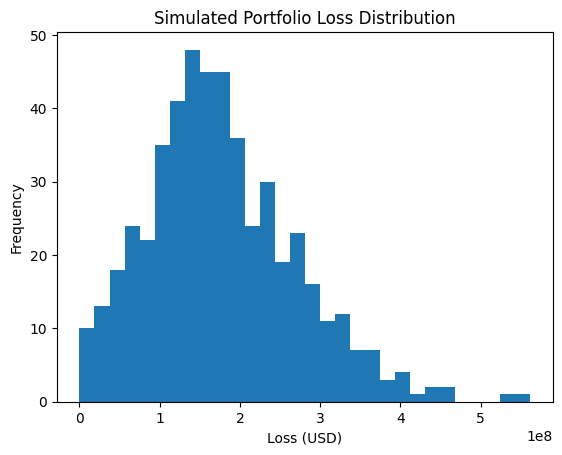

In [12]:
plt.hist(portfolio_losses, bins=30)
plt.title("Simulated Portfolio Loss Distribution")
plt.xlabel("Loss (USD)")
plt.ylabel("Frequency")
plt.show()